Epoch 1/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 839s 187ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 2/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 660s 151ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 3/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 658s 150ms/step - loss: 0.0026 - val_loss: 0.0031
Epoch 4/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 536s 122ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 5/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 538s 123ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 6/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 553s 126ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 7/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 528s 121ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 8/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 532s 121ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 9/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 534s 122ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 10/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 532s 121ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 11/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 534s 122ms/step - loss: 0.0013 - val

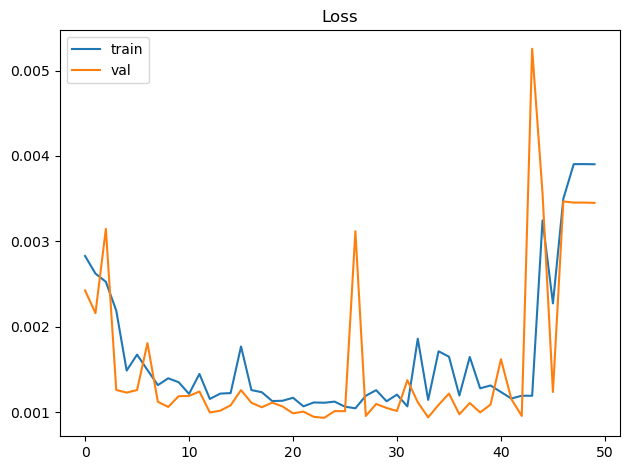

274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step
MAE: 19.894338607788086
RMSE: 30.64305709687249
R2: -0.0004965066909790039


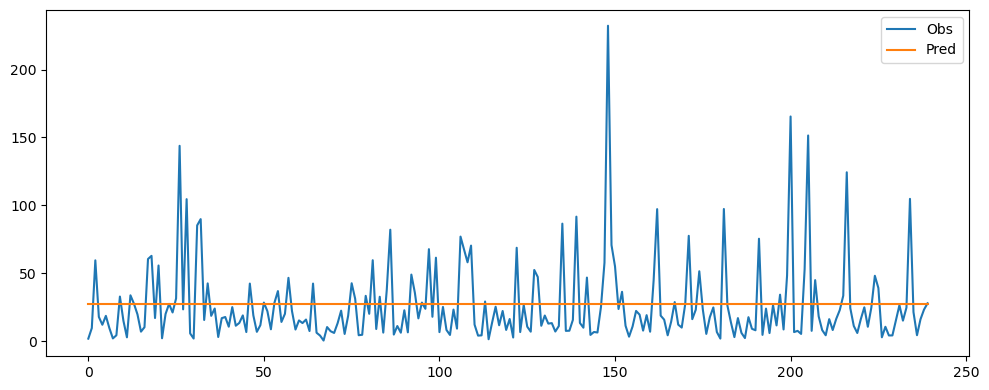

274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step


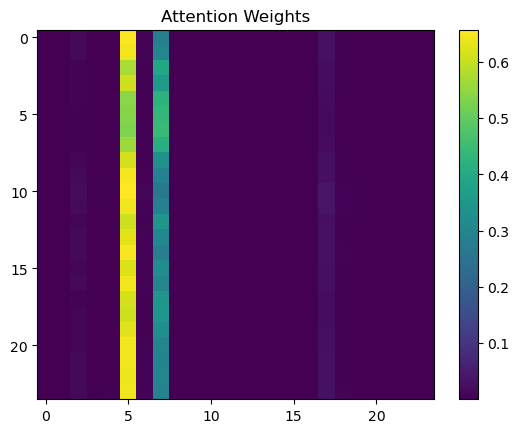

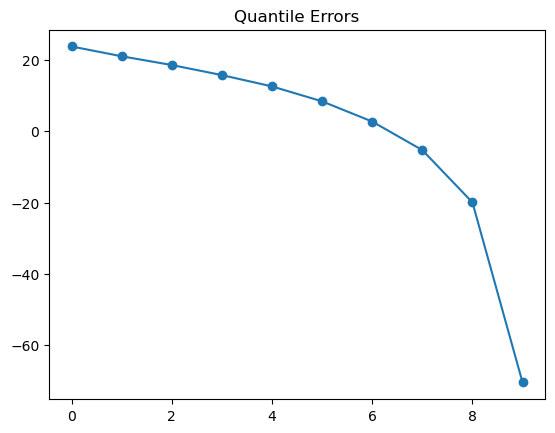

In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib import rcParams
from keras.layers import (
    Input, Conv2D, MaxPooling2D,
    TimeDistributed, Flatten, Dense,
    MultiHeadAttention)
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Load & merge your two stations into a 2×13 grid
stations = ['eMalahleni','Middelburg']
dfs = []
for st in stations:
    df = pd.read_csv(f"C:\\Users\\User\\Documents\\GitHub\\Health-impacts-of-air-pollution\\AirData\\{st}IM.csv", sep=';', index_col=0)
    df.columns = [f"{st}_{c}" for c in df.columns]
    dfs.append(df)
data   = pd.concat(dfs, axis=1).dropna()
values = data.values.astype('float32')

# 2) Frame as supervised with n_in=6 timesteps
def series_to_supervised(data, n_in=1, n_out=1):
    df = pd.DataFrame(data)
    cols, names = [], []
    n_vars = df.shape[1]
    # past lags
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [f"var{j+1}(t-{i})" for j in range(n_vars)]
    # future steps
    for i in range(n_out):
        cols.append(df.shift(-i))
        suffix = '' if i==0 else f'+{i}'
        names += [f"var{j+1}(t{suffix})" for j in range(n_vars)]
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    agg.dropna(inplace=True)
    return agg

scaler   = MinMaxScaler((0,1))
scaled   = scaler.fit_transform(values)
n_in     = 24
n_vars   = scaled.shape[1]
reframed = series_to_supervised(scaled, n_in, 1)

# 3) Keep only the lag‑inputs and the first var (PM2.5) as target
n_obs    = n_in * n_vars
df_trim  = reframed.iloc[:, list(range(n_obs)) + [n_obs]]
vals     = df_trim.values
X_all, Y = vals[:, :n_obs], vals[:, -1]

# 4) reshape X → [samples, timesteps, stations, features, 1]
n_stations = 2
n_feats    = n_vars // n_stations  # 13
X = X_all.reshape((-1, n_in, n_stations, n_feats, 1))

# 5) split
X_train, X_tmp, Y_train, Y_tmp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val,   X_test,  Y_val,   Y_test  = train_test_split(X_tmp, Y_tmp, test_size=0.5, random_state=42)

# 6) build TimeDistributed 2D‑CNN + MHA
inp = Input(shape=(n_in, n_stations, n_feats, 1), name='input')

# apply identical Conv2D blocks at each timestep
td = TimeDistributed(Conv2D(128, (2,2), activation='relu', padding='same'), name='td_conv1')(inp)
td = TimeDistributed(MaxPooling2D((1,2)), name='td_pool1')(td)
td = TimeDistributed(Conv2D(128, (2,2), activation='relu', padding='same'), name='td_conv2')(td)
td = TimeDistributed(MaxPooling2D((1,2)), name='td_pool2')(td)
td = TimeDistributed(Conv2D(128, (2,2), activation='relu', padding='same'), name='td_conv3')(td)
td = TimeDistributed(MaxPooling2D((1,2)), name='td_pool3')(td)

# flatten spatial dims but keep timesteps
td_flat = TimeDistributed(Flatten(), name='td_flat')(td)
# shape now: (batch, n_in, spatial_feats)

# self‑attention across the 6 timesteps
mha = MultiHeadAttention(num_heads=4, key_dim=td_flat.shape[-1], name='mha')
attn_out = mha(query=td_flat, value=td_flat, key=td_flat)

# collapse and head
x = Flatten(name='flatten_all')(attn_out)
for i in range(5):
    x = Dense(56, activation='relu', name=f'dense{i+1}')(x)
pred = Dense(1, activation='linear', name='pred')(x)

model = Model(inputs=inp, outputs=pred)
model.compile(optimizer='adam', loss='mse')

# 7) train
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=16, verbose=1)


In [ ]:
# 9) predict & invert scaling
pred_sc = model.predict(X_test)
y_pred  = pred_sc.flatten()*(scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]
y_true  = Y_test    *(scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

# 10) metrics & Pred vs Obs
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", sqrt(mean_squared_error(y_true, y_pred)))
print("R2:",   r2_score(y_true, y_pred))

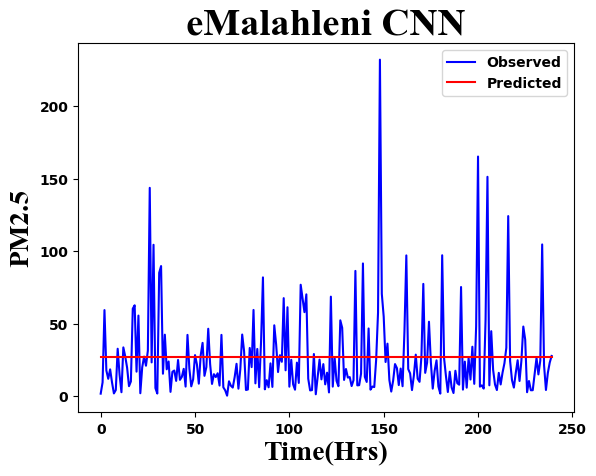

In [8]:
rcParams['font.weight'] = 'bold'
plt.plot(y_true[0:240], color='blue', label = 'Observed')
plt.plot(y_pred[0:240], color='red', label = 'Predicted')
plt.ylabel('PM2.5', fontname="Times New Roman", size=20,fontweight="bold")
plt.xlabel('Time(Hrs)', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('eMalahleni CNN', fontname="Times New Roman", size=28,fontweight="bold")
legend_properties = {'weight':'bold'}
plt.legend(prop=legend_properties)
plt.show()

In [ ]:
# 11) attention heatmap for sample 0, head 0
# build inference model to extract scores
inf_inp = Input(shape=(n_in, n_stations, n_feats,1))
y = model.get_layer('td_conv1')(inf_inp)
y = model.get_layer('td_pool1')(y)
y = model.get_layer('td_conv2')(y)
y = model.get_layer('td_pool2')(y)
y = model.get_layer('td_conv3')(y)
y = model.get_layer('td_pool3')(y)
y = model.get_layer('td_flat')(y)
# now get scores
_, scores = mha(
    query=y, value=y, key=y, return_attention_scores=True)
attn_model = Model(inputs=inf_inp, outputs=scores)

scores_np = attn_model.predict(X_test)
heatmap   = scores_np[0, 0, :, :]  # sample 0, head 0
plt.imshow(heatmap, aspect='auto', cmap='viridis')
plt.colorbar(); plt.title('Attention Weights'); plt.show()

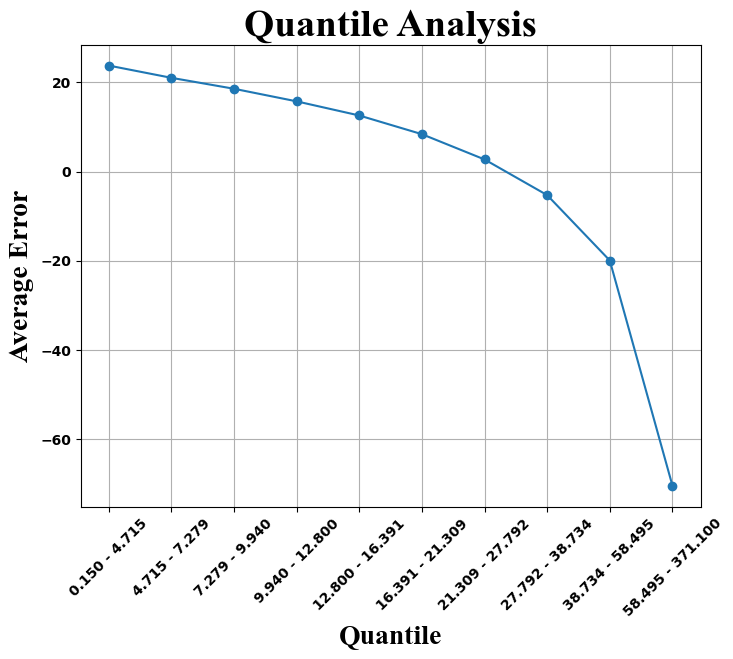

In [9]:
errors = predictions.flatten() - Y_tests

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(Y_tests, q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((Y_tests >= bins[i]) & (Y_tests < bins[i+1]))[0]
    quantile_errors.append(errors[group_indices].mean())

# Round the bin edges for better readability
rounded_bins = np.round(bins, decimals=3)

# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20, fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20, fontweight="bold")
plt.title('Quantile Analysis', fontname="Times New Roman", size=28, fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [f'{rounded_bins[i]:.3f} - {rounded_bins[i+1]:.3f}' for i in range(len(rounded_bins) - 1)], rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# 13) SHAP (in a fresh kernel or **after** saving & reloading)
import shap  
bg = X_train[np.random.choice(len(X_train),100,False)].reshape(100, -1)
tf = X_test[np.random.choice(len(X_test),20,False)].reshape(20, -1)
f = lambda x: model.predict(x.reshape(-1,n_in,n_stations,n_feats,1)).flatten()
explainer = shap.KernelExplainer(f, bg)
shap_vals = explainer.shap_values(tf)
feat_names = [f"{col}_t-{lag}" for lag in range(n_in,0,-1) for col in data.columns]
shap.summary_plot(shap_vals, tf, feature_names=feat_names)